<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



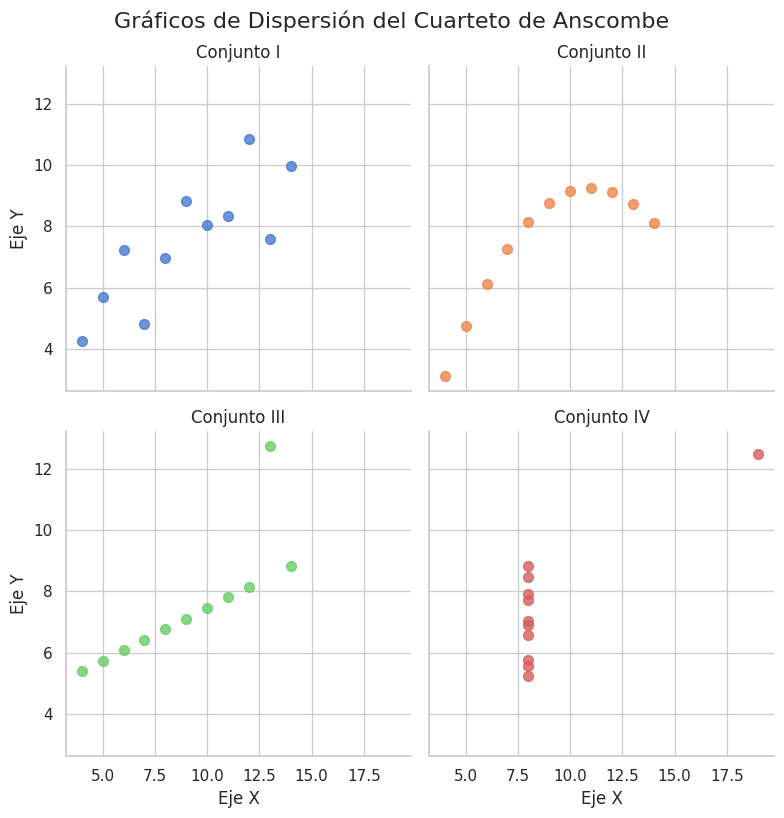

In [6]:
g = sns.lmplot(x="x", y="y", col="dataset", hue="dataset", data=data,
               col_wrap=2, ci=None, palette="muted", height=4, scatter_kws={"s": 50, "alpha": 0.8}, fit_reg=False)
g.set_axis_labels("Eje X", "Eje Y")
g.set_titles("Conjunto {col_name}")
plt.suptitle('Gráficos de Dispersión del Cuarteto de Anscombe', y=1.02, fontsize=16)
plt.show()

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [7]:
data.groupby('dataset').describe()

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



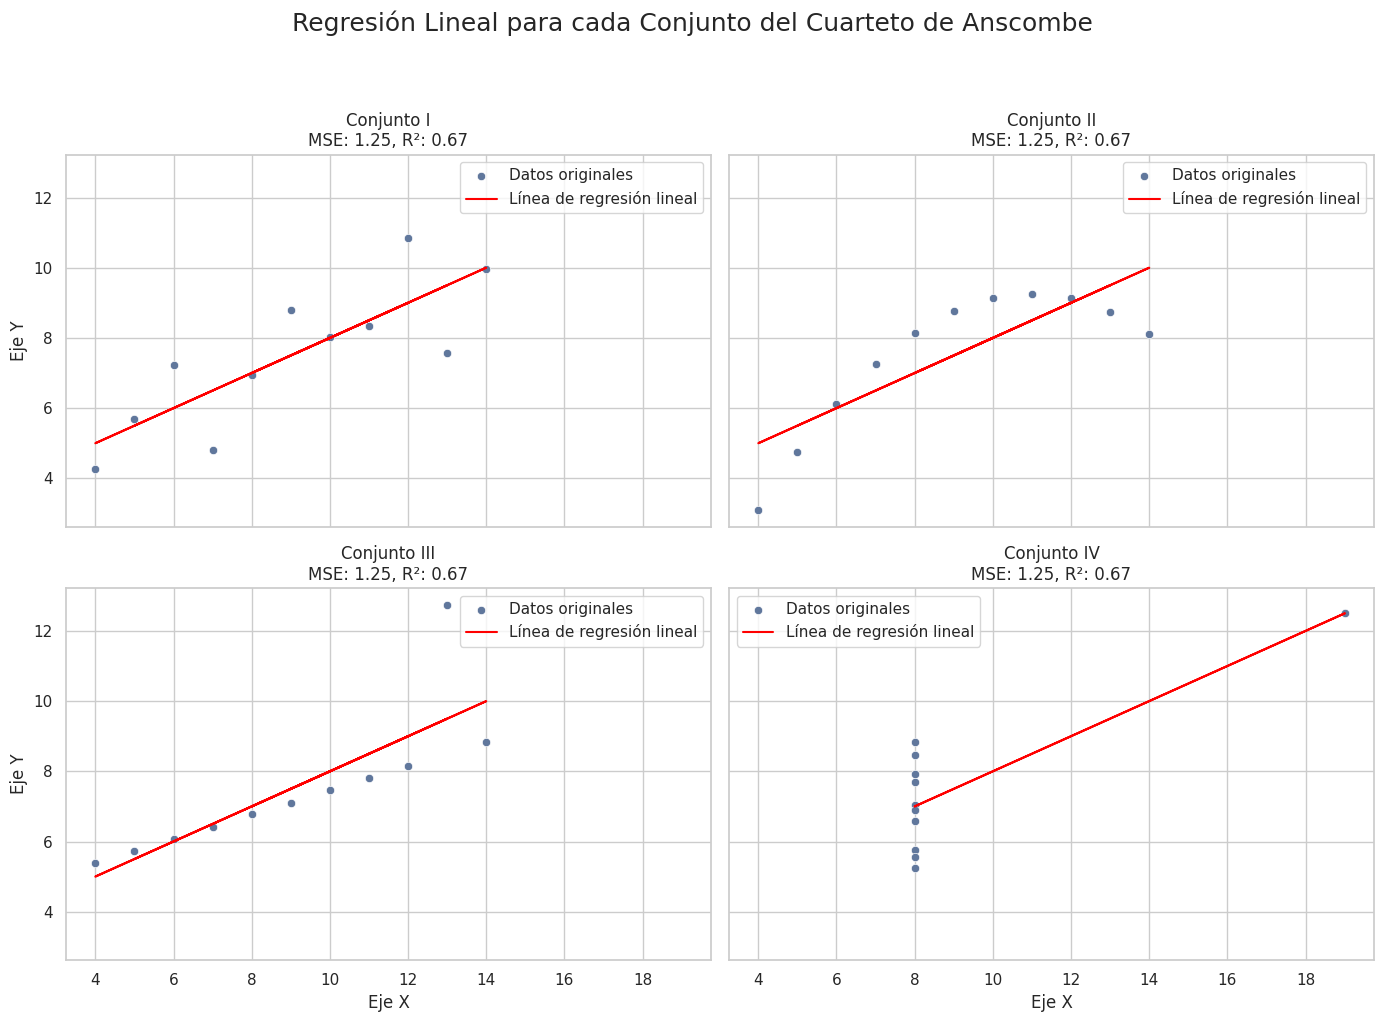

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, dataset_name in enumerate(data['dataset'].unique()):
    subset = data[data['dataset'] == dataset_name]
    X = subset[['x']]
    y = subset['y']

    # Ajustar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    # Calcular métricas
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Graficar los resultados
    ax = axes[i]
    sns.scatterplot(x='x', y='y', data=subset, ax=ax, label='Datos originales')
    ax.plot(X, y_pred, color='red', label='Línea de regresión lineal')
    ax.set_title(f'Conjunto {dataset_name}\nMSE: {mse:.2f}, R²: {r2:.2f}')
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.legend()

plt.suptitle('Regresión Lineal para cada Conjunto del Cuarteto de Anscombe', y=1.02, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.

Conjunto II (Regresión Polinomial):
  MSE: 0.00
  R²: 1.00


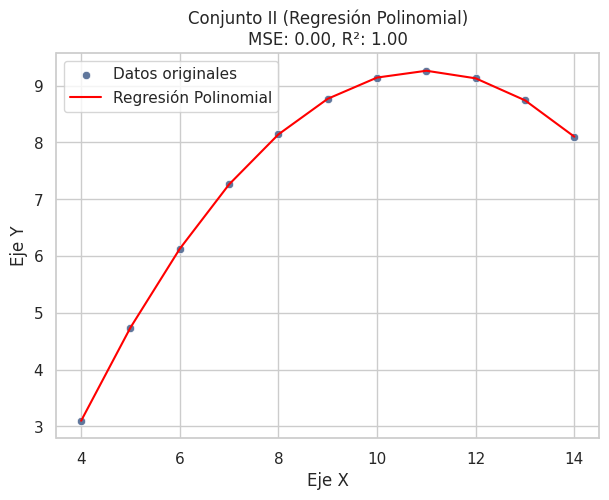


##################################################

Conjunto III (Lineal sin Outlier):
  MSE: 0.00
  R²: 1.00


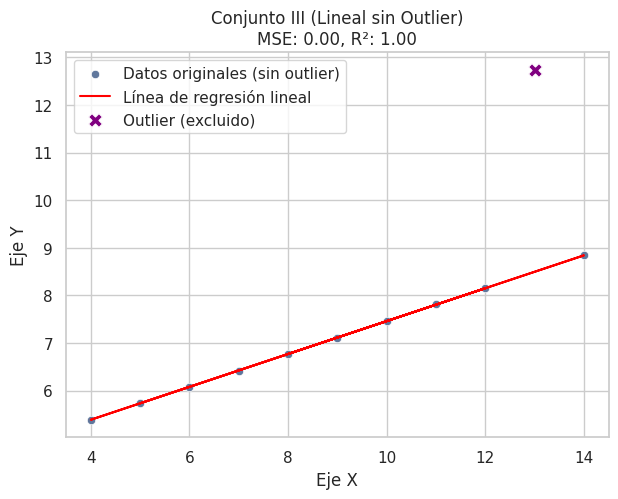


##################################################

#### Conjunto IV: Impacto del Punto de Alto Apalancamiento

En el Conjunto IV, la mayoría de los puntos tienen el mismo valor de 'x' (8.0), excepto un único punto con x=19.0. Este punto actúa como un punto de alto apalancamiento que influye desproporcionadamente en la pendiente del modelo de regresión lineal. Eliminar este punto convertiría el problema en uno sin varianza en 'x' para la mayoría de los puntos, haciendo que la regresión lineal sea inviable o trivial. Una estrategia aquí podría ser:
1.  **Regresión Robusta:** Utilizar modelos de regresión que sean menos sensibles a puntos de alto apalancamiento (ej. RANSAC, Theil-Sen Estimator, o Huber Regressor).
2.  **Análisis Separado:** Reconocer que la mayoría de los datos se agrupan en un solo valor de 'x' y analizar esa distribución por separado, mientras que el punto atípico (x=19.0) podría indicar una condición o subgrupo diferente que merece un estudio individual.
3.  **No usa

In [9]:
# --- Estrategia para el Conjunto II: Regresión Polinomial ---

# Filtrar el Conjunto II
subset_II = data[data['dataset'] == 'II']
X_II = subset_II[['x']]
y_II = subset_II['y']

# Crear características polinomiales (grado 2)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly_II = poly.fit_transform(X_II)

# Ajustar el modelo de regresión lineal a las características polinomiales
model_poly_II = LinearRegression()
model_poly_II.fit(X_poly_II, y_II)
y_pred_poly_II = model_poly_II.predict(X_poly_II)

# Calcular métricas para el modelo polinomial
mse_poly_II = mean_squared_error(y_II, y_pred_poly_II)
r2_poly_II = r2_score(y_II, y_pred_poly_II)

print(f"Conjunto II (Regresión Polinomial):")
print(f"  MSE: {mse_poly_II:.2f}")
print(f"  R²: {r2_poly_II:.2f}")

# Graficar los resultados del modelo polinomial
plt.figure(figsize=(7, 5))
sns.scatterplot(x='x', y='y', data=subset_II, label='Datos originales')
# Ordenar los datos para una línea de regresión suave
sorted_zip = sorted(zip(X_II['x'], y_pred_poly_II))
x_poly_plot, y_poly_plot = zip(*sorted_zip)
plt.plot(x_poly_plot, y_poly_plot, color='red', label='Regresión Polinomial')
plt.title(f'Conjunto II (Regresión Polinomial)\nMSE: {mse_poly_II:.2f}, R²: {r2_poly_II:.2f}')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.legend()
plt.show()

# --- Estrategia para el Conjunto III: Remoción de Outliers ---

print("\n" + "#"*50 + "\n")

# Filtrar el Conjunto III
subset_III = data[data['dataset'] == 'III']

# Identificar y eliminar el outlier (visualizando, es el punto con y más alta)
# Podemos identificarlo por su valor de y inusualmente alto para un x=13
outlier_III = subset_III[subset_III['y'] > 12] # Identificación basada en la observación del gráfico
subset_III_cleaned = subset_III.drop(outlier_III.index)

X_III_cleaned = subset_III_cleaned[['x']]
y_III_cleaned = subset_III_cleaned['y']

# Ajustar un modelo de regresión lineal al conjunto limpio
model_cleaned_III = LinearRegression()
model_cleaned_III.fit(X_III_cleaned, y_III_cleaned)
y_pred_cleaned_III = model_cleaned_III.predict(X_III_cleaned)

# Calcular métricas para el modelo limpio
mse_cleaned_III = mean_squared_error(y_III_cleaned, y_pred_cleaned_III)
r2_cleaned_III = r2_score(y_III_cleaned, y_pred_cleaned_III)

print(f"Conjunto III (Lineal sin Outlier):")
print(f"  MSE: {mse_cleaned_III:.2f}")
print(f"  R²: {r2_cleaned_III:.2f}")

# Graficar los resultados del modelo lineal sin el outlier
plt.figure(figsize=(7, 5))
sns.scatterplot(x='x', y='y', data=subset_III_cleaned, label='Datos originales (sin outlier)')
plt.plot(X_III_cleaned, y_pred_cleaned_III, color='red', label='Línea de regresión lineal')
sns.scatterplot(x='x', y='y', data=outlier_III, color='purple', marker='X', s=100, label='Outlier (excluido)') # Opcional: mostrar el outlier excluido
plt.title(f'Conjunto III (Lineal sin Outlier)\nMSE: {mse_cleaned_III:.2f}, R²: {r2_cleaned_III:.2f}')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.legend()
plt.show()

# --- Discusión para el Conjunto IV ---

print("\n" + "#"*50 + "\n")

print("#### Conjunto IV: Impacto del Punto de Alto Apalancamiento\n")
print("En el Conjunto IV, la mayoría de los puntos tienen el mismo valor de 'x' (8.0), excepto un único punto con x=19.0. Este punto actúa como un punto de alto apalancamiento que influye desproporcionadamente en la pendiente del modelo de regresión lineal. Eliminar este punto convertiría el problema en uno sin varianza en 'x' para la mayoría de los puntos, haciendo que la regresión lineal sea inviable o trivial. Una estrategia aquí podría ser:")
print("1.  **Regresión Robusta:** Utilizar modelos de regresión que sean menos sensibles a puntos de alto apalancamiento (ej. RANSAC, Theil-Sen Estimator, o Huber Regressor).")
print("2.  **Análisis Separado:** Reconocer que la mayoría de los datos se agrupan en un solo valor de 'x' y analizar esa distribución por separado, mientras que el punto atípico (x=19.0) podría indicar una condición o subgrupo diferente que merece un estudio individual.")
print("3.  **No usar regresión lineal:** Si la relación no es inherentemente lineal o la varianza en X es mínima, la regresión lineal puede no ser la herramienta apropiada.")
print("En este caso particular, la regresión lineal sigue el punto atípico porque es el único que proporciona 'apalancamiento' para definir una pendiente, lo que resulta en un modelo poco representativo para el resto de los datos.")
